<a href="https://colab.research.google.com/github/Shaurya-XD/diabetic_retinopathy/blob/main/Messidor2_EXTERNAL_VALIDATION_LABELED_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Messidor-2 External Validation — Final Trained DR Classifier

This notebook performs **quantitative external validation only**. It does **not retrain** the APTOS EfficientNetB0 classifier or the IDRiD U-Net.

It is built for the Drive layout:

```text
sih/
├── outputs_v3/
│   ├── aptos_efficientnetb0_final.keras
│   └── run_summary.json
├── outputs_v3_fixed/
└── messidor2_external_validation.zip
```

The uploaded ZIP may contain the nested structure:

```text
archive/
├── messidor_data.csv
└── messidor-2/
    └── messidor-2/
        └── preprocess/
            └── fundus images
```

The notebook deliberately discovers `messidor_data.csv` and the deepest usable `preprocess/` directory recursively, so the repeated `messidor-2/messidor-2` folders are fine.

## Evaluation policy

- Existing classifier checkpoint only — **no training**.
- Existing APTOS-derived temperature is frozen.
- Existing APTOS-validation referral threshold is frozen.
- Referable DR is defined as **grade ≥ 2**.
- Messidor is used only as an **external test dataset**.
- Rows with missing/invalid DR grade are excluded.
- If an explicit gradability column marks an image ungradable, that row is excluded.
- The notebook verifies filename matching before running metrics.


In [2]:

# Cell 1 — Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:

# Cell 2 — Imports and reproducibility
import os
import json
import shutil
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras

from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python/TensorFlow environment ready.")
print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


Python/TensorFlow environment ready.
TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:

# Cell 3 — Locate the SIH project, final model, summary, and new Messidor ZIP
MYDRIVE = Path("/content/drive/MyDrive")

def find_in_mydrive(filename, preferred=None):
    if preferred is not None and preferred.exists():
        return preferred

    matches = list(MYDRIVE.rglob(filename))
    if not matches:
        return None

    if len(matches) > 1:
        print(f"WARNING: multiple {filename} files found. Using:", matches[0])
    return matches[0]

preferred_root = MYDRIVE / "sih"
preferred_zip = preferred_root / "messidor2_external_validation.zip"
preferred_model = preferred_root / "outputs_v3" / "aptos_efficientnetb0_final.keras"
preferred_summary = preferred_root / "outputs_v3" / "run_summary.json"

MESSIDOR_ZIP = find_in_mydrive(
    "messidor2_external_validation.zip",
    preferred_zip,
)
FINAL_CLASSIFIER = find_in_mydrive(
    "aptos_efficientnetb0_final.keras",
    preferred_model,
)
RUN_SUMMARY = find_in_mydrive(
    "run_summary.json",
    preferred_summary,
)

missing = []
if MESSIDOR_ZIP is None:
    missing.append("messidor2_external_validation.zip")
if FINAL_CLASSIFIER is None:
    missing.append("aptos_efficientnetb0_final.keras")
if RUN_SUMMARY is None:
    missing.append("run_summary.json")

if missing:
    raise FileNotFoundError(
        "Could not find: " + ", ".join(missing) + "\n\n"
        "If the 'sih' folder is only under 'Shared with me', add a shortcut "
        "for that folder to My Drive and rerun this cell."
    )

# Infer the SIH root from the model location when possible.
OUTPUT_V3 = FINAL_CLASSIFIER.parent
DRIVE_ROOT = OUTPUT_V3.parent
FIXED_OUTPUT_ROOT = DRIVE_ROOT / "outputs_v3_fixed"
EXTERNAL_OUTPUT_ROOT = FIXED_OUTPUT_ROOT / "messidor_external_validation"
EXTERNAL_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("DRIVE_ROOT:", DRIVE_ROOT)
print("Classifier:", FINAL_CLASSIFIER)
print("Run summary:", RUN_SUMMARY)
print("Messidor ZIP:", MESSIDOR_ZIP)
print("External outputs:", EXTERNAL_OUTPUT_ROOT)


DRIVE_ROOT: /content/drive/MyDrive/sih
Classifier: /content/drive/MyDrive/sih/outputs_v3/aptos_efficientnetb0_final.keras
Run summary: /content/drive/MyDrive/sih/outputs_v3/run_summary.json
Messidor ZIP: /content/drive/MyDrive/sih/messidor2_external_validation.zip
External outputs: /content/drive/MyDrive/sih/outputs_v3_fixed/messidor_external_validation


In [5]:

# Cell 4 — Restore the exact successful-run configuration
with open(RUN_SUMMARY, "r", encoding="utf-8") as f:
    previous_summary = json.load(f)

CLS_SIZE = tuple(previous_summary["config"]["cls_size"])
TEMPERATURE = float(previous_summary["classifier"]["temperature"])
REF_THRESHOLD = float(previous_summary["classifier"]["referral_threshold"])

print("Classifier input size:", CLS_SIZE)
print("Frozen temperature:", TEMPERATURE)
print("Frozen referral threshold:", REF_THRESHOLD)

# These MUST remain frozen for an honest external test.
assert len(CLS_SIZE) == 2
assert 0.0 < REF_THRESHOLD < 1.0
assert TEMPERATURE > 0.0


Classifier input size: (300, 300)
Frozen temperature: 0.8320230381499122
Frozen referral threshold: 0.3188608191210113


In [6]:

# Cell 5 — Load the final selected APTOS classifier (NO retraining)
model = keras.models.load_model(
    FINAL_CLASSIFIER,
    compile=False,
)

print("Classifier restored.")
print("Model name:", model.name)
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

if tuple(model.input_shape[1:3]) != tuple(CLS_SIZE):
    raise RuntimeError(
        f"Checkpoint input size {model.input_shape[1:3]} does not match "
        f"run_summary CLS_SIZE={CLS_SIZE}."
    )

if int(model.output_shape[-1]) != 5:
    raise RuntimeError(
        f"Expected 5 DR grade outputs, got {model.output_shape}."
    )


Classifier restored.
Model name: DR_EfficientNetB0
Input shape: (None, 300, 300, 3)
Output shape: (None, 5)


In [7]:

# Cell 6 — Extract the new labeled/preprocessed Messidor-2 archive
WORK_ROOT = Path("/content/messidor2_external_validation")

if WORK_ROOT.exists():
    shutil.rmtree(WORK_ROOT)

WORK_ROOT.mkdir(parents=True, exist_ok=True)

print("Extracting:", MESSIDOR_ZIP)
with zipfile.ZipFile(MESSIDOR_ZIP, "r") as zf:
    zf.extractall(WORK_ROOT)

print("Extraction complete:", WORK_ROOT)

# Show a compact directory preview.
for p in sorted(WORK_ROOT.rglob("*"))[:40]:
    print(" -", p.relative_to(WORK_ROOT))


Extracting: /content/drive/MyDrive/sih/messidor2_external_validation.zip
Extraction complete: /content/messidor2_external_validation
 - messidor-2
 - messidor-2/messidor-2
 - messidor-2/messidor-2/preprocess
 - messidor-2/messidor-2/preprocess/20051020_43808_0100_PP.png
 - messidor-2/messidor-2/preprocess/20051020_43832_0100_PP.png
 - messidor-2/messidor-2/preprocess/20051020_43882_0100_PP.png
 - messidor-2/messidor-2/preprocess/20051020_43906_0100_PP.png
 - messidor-2/messidor-2/preprocess/20051020_44261_0100_PP.png
 - messidor-2/messidor-2/preprocess/20051020_44284_0100_PP.png
 - messidor-2/messidor-2/preprocess/20051020_44338_0100_PP.png
 - messidor-2/messidor-2/preprocess/20051020_44349_0100_PP.png
 - messidor-2/messidor-2/preprocess/20051020_44400_0100_PP.png
 - messidor-2/messidor-2/preprocess/20051020_44431_0100_PP.png
 - messidor-2/messidor-2/preprocess/20051020_44598_0100_PP.png
 - messidor-2/messidor-2/preprocess/20051020_44636_0100_PP.png
 - messidor-2/messidor-2/preprocess/

In [8]:

# Cell 7 — Locate messidor_data.csv and the nested preprocess image directory
IMG_EXTS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".bmp"}

csv_matches = list(WORK_ROOT.rglob("messidor_data.csv"))
if not csv_matches:
    raise FileNotFoundError(
        "messidor_data.csv was not found anywhere inside the extracted ZIP."
    )

MESSIDOR_CSV = csv_matches[0]

preprocess_candidates = []
for d in WORK_ROOT.rglob("preprocess"):
    if not d.is_dir():
        continue
    images = [
        p for p in d.rglob("*")
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    ]
    if images:
        preprocess_candidates.append((d, len(images)))

if not preprocess_candidates:
    raise FileNotFoundError(
        "No preprocess/ folder containing fundus images was found."
    )

preprocess_candidates.sort(key=lambda x: x[1], reverse=True)
MESSIDOR_IMAGE_ROOT, image_count = preprocess_candidates[0]

print("CSV:", MESSIDOR_CSV)
print("Selected preprocess directory:", MESSIDOR_IMAGE_ROOT)
print("Fundus image files found:", image_count)

print("\nAll preprocess candidates:")
for d, n in preprocess_candidates:
    print(f" - {d}: {n} images")


CSV: /content/messidor2_external_validation/messidor_data.csv
Selected preprocess directory: /content/messidor2_external_validation/messidor-2/messidor-2/preprocess
Fundus image files found: 1744

All preprocess candidates:
 - /content/messidor2_external_validation/messidor-2/messidor-2/preprocess: 1744 images


In [9]:

# Cell 8 — Read and inspect messidor_data.csv
def robust_read_csv(path):
    attempts = []

    try:
        attempts.append(("auto", pd.read_csv(path, sep=None, engine="python")))
    except Exception:
        pass

    for sep, name in [
        (",", "comma"),
        (";", "semicolon"),
        ("\t", "tab"),
        ("|", "pipe"),
    ]:
        try:
            attempts.append((name, pd.read_csv(path, sep=sep)))
        except Exception:
            pass

    attempts = [
        (name, df)
        for name, df in attempts
        if df is not None and len(df) > 0
    ]

    if not attempts:
        raise ValueError("Could not parse messidor_data.csv.")

    attempts.sort(
        key=lambda item: (
            item[1].shape[1],
            int(item[1].notna().sum().sum()),
        ),
        reverse=True,
    )
    return attempts[0]

parse_type, raw = robust_read_csv(MESSIDOR_CSV)
raw = raw.copy()
raw.columns = [str(c).strip() for c in raw.columns]

print("=" * 72)
print("MESSIDOR DATA INSPECTION")
print("=" * 72)
print("Parse:", parse_type)
print("Shape:", raw.shape)
print("Columns:", list(raw.columns))
display(raw.head(10))

print("\nNull counts:")
display(raw.isna().sum().to_frame("null_count"))


MESSIDOR DATA INSPECTION
Parse: auto
Shape: (1744, 4)
Columns: ['id_code', 'diagnosis', 'adjudicated_dme', 'adjudicated_gradable']


,id_code,diagnosis,adjudicated_dme,adjudicated_gradable
0,20051020_43808_0100_PP.png,0,0,1
1,20051020_43832_0100_PP.png,1,0,1
2,20051020_43882_0100_PP.png,1,0,1
3,20051020_43906_0100_PP.png,2,1,1
4,20051020_44261_0100_PP.png,0,0,1
5,20051020_44284_0100_PP.png,0,0,1
6,20051020_44338_0100_PP.png,0,0,1
7,20051020_44349_0100_PP.png,2,0,1
8,20051020_44400_0100_PP.png,0,0,1
9,20051020_44431_0100_PP.png,0,0,1



Null counts:


,null_count
id_code,0
diagnosis,0
adjudicated_dme,0
adjudicated_gradable,0


In [10]:

# Cell 9 — Index images and reliably identify image + DR-grade columns
image_paths = [
    p for p in MESSIDOR_IMAGE_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in IMG_EXTS
]

image_index = pd.DataFrame({
    "filepath": [str(p) for p in image_paths],
    "filename": [p.name for p in image_paths],
    "stem": [p.stem.lower() for p in image_paths],
})

# One path per normalized stem.
path_by_stem = {}
for _, row in image_index.iterrows():
    path_by_stem.setdefault(row["stem"], row["filepath"])

image_stems = set(path_by_stem)

def normalize_image_key(value):
    if pd.isna(value):
        return None
    s = str(value).strip().strip('"').strip("'")
    if not s:
        return None
    return Path(s).stem.lower()

def image_match_rate(series):
    keys = series.map(normalize_image_key)
    valid = keys.notna()
    if valid.sum() == 0:
        return 0.0
    return float(keys[valid].isin(image_stems).mean())

image_scores = {
    c: image_match_rate(raw[c])
    for c in raw.columns
}

print("Image-column match scores:")
for c, score in sorted(image_scores.items(), key=lambda x: x[1], reverse=True):
    print(f" - {c!r}: {score:.4f}")

IMAGE_COL = max(image_scores, key=image_scores.get)
IMAGE_MATCH_RATE = image_scores[IMAGE_COL]

if IMAGE_MATCH_RATE < 0.50:
    raise RuntimeError(
        "No CSV column matches the Messidor image filenames reliably. "
        f"Best column={IMAGE_COL!r}, match_rate={IMAGE_MATCH_RATE:.3f}."
    )

print("\nSelected image column:", IMAGE_COL)
print("Filename match rate:", IMAGE_MATCH_RATE)

TEXT_GRADE_MAP = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "no dr": 0,
    "no diabetic retinopathy": 0,
    "normal": 0,
    "none": 0,
    "mild": 1,
    "mild dr": 1,
    "moderate": 2,
    "moderate dr": 2,
    "severe": 3,
    "severe dr": 3,
    "proliferative": 4,
    "proliferative dr": 4,
    "pdr": 4,
}

def coerce_grade_series(series):
    numeric = pd.to_numeric(series, errors="coerce")

    original_nonnull = series.notna().sum()
    if original_nonnull > 0 and numeric.notna().sum() / original_nonnull >= 0.70:
        return numeric

    normalized = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .str.replace("_", " ", regex=False)
        .str.replace("-", " ", regex=False)
    )
    return normalized.map(TEXT_GRADE_MAP)

def is_valid_dr_grade_series(series):
    grades = coerce_grade_series(series)
    valid = grades.dropna()

    if len(valid) < max(20, int(0.25 * len(series))):
        return False, grades

    vals = valid.to_numpy(dtype=float)
    rounded = np.round(vals).astype(int)

    integer_fraction = float(np.mean(np.isclose(vals, rounded)))
    in_range_fraction = float(np.mean((rounded >= 0) & (rounded <= 4)))
    unique_values = set(rounded.tolist())

    ok = (
        integer_fraction >= 0.95
        and in_range_fraction >= 0.95
        and len(unique_values) >= 2
        and unique_values.issubset({0, 1, 2, 3, 4})
    )
    return ok, grades

# Prefer known DR target names explicitly.
preferred_grade_names = [
    "adjudicated_dr_grade",
    "diagnosis",
    "dr_grade",
    "dr grade",
    "retinopathy_grade",
    "retinopathy grade",
    "severity",
]

GRADE_COL = None
grade_series = None

lower_to_original = {
    str(c).strip().lower(): c
    for c in raw.columns
}

for preferred in preferred_grade_names:
    if preferred in lower_to_original:
        candidate = lower_to_original[preferred]
        ok, grades = is_valid_dr_grade_series(raw[candidate])
        if ok:
            GRADE_COL = candidate
            grade_series = grades
            break

# Fallback heuristic if no exact preferred name exists.
if GRADE_COL is None:
    candidate_scores = []

    for c in raw.columns:
        if c == IMAGE_COL:
            continue

        ok, grades = is_valid_dr_grade_series(raw[c])
        if not ok:
            continue

        lname = str(c).strip().lower()
        score = 0.0

        for token, weight in [
            ("adjudicated_dr_grade", 30.0),
            ("diagnosis", 20.0),
            ("dr_grade", 15.0),
            ("retinopathy", 10.0),
            ("severity", 8.0),
            ("grade", 6.0),
            ("diagn", 5.0),
            ("dr", 4.0),
        ]:
            if token in lname:
                score += weight

        for bad in [
            "dme",
            "edema",
            "oedema",
            "gradable",
            "gradability",
            "quality",
            "left",
            "right",
            "pair",
            "index",
        ]:
            if bad in lname:
                score -= 20.0

        candidate_scores.append((score, c, grades))

    candidate_scores.sort(key=lambda x: x[0], reverse=True)

    print("\nFallback DR-grade candidates:")
    for score, c, grades in candidate_scores:
        vals = sorted(
            set(np.round(grades.dropna().to_numpy(dtype=float)).astype(int))
        )
        print(
            f" - {c!r}: score={score:.1f}, "
            f"values={vals}, n={grades.notna().sum()}"
        )

    if candidate_scores and candidate_scores[0][0] > 0:
        _, GRADE_COL, grade_series = candidate_scores[0]

if GRADE_COL is None:
    raise RuntimeError(
        "No trustworthy DR-grade column was detected. "
        "Inspect the printed CSV columns before proceeding."
    )

raw["__grade"] = grade_series

print("\nSelected DR-grade column:", GRADE_COL)
print(
    "Detected grade values:",
    sorted(
        set(
            np.round(
                raw["__grade"].dropna().to_numpy(dtype=float)
            ).astype(int)
        )
    )
)
print("Non-null DR labels:", int(raw["__grade"].notna().sum()))

gradable_candidates = [
    c for c in raw.columns
    if "gradable" in c.lower() or "gradability" in c.lower()
]
GRADABLE_COL = gradable_candidates[0] if gradable_candidates else None
print("Gradability column:", GRADABLE_COL)


Image-column match scores:
 - 'id_code': 1.0000
 - 'diagnosis': 0.0000
 - 'adjudicated_dme': 0.0000
 - 'adjudicated_gradable': 0.0000

Selected image column: id_code
Filename match rate: 1.0

Selected DR-grade column: diagnosis
Detected grade values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Non-null DR labels: 1744
Gradability column: adjudicated_gradable


In [11]:

# Cell 10 — Build the external validation manifest and audit matching
ext = raw.copy()
ext["__image_key"] = ext[IMAGE_COL].map(normalize_image_key)
ext["filepath"] = ext["__image_key"].map(path_by_stem)

rows_total = len(ext)
rows_with_image_match = int(ext["filepath"].notna().sum())
rows_with_grade = int(ext["__grade"].notna().sum())

# Exclude rows explicitly marked ungradable, if a gradability field exists.
def explicit_ungradable(value):
    if pd.isna(value):
        return False
    s = str(value).strip().lower()
    return s in {
        "0", "false", "f", "no", "n",
        "ungradable", "not gradable", "not_gradable",
    }

if GRADABLE_COL is not None:
    ungradable_mask = ext[GRADABLE_COL].map(explicit_ungradable)
    explicit_ungradable_count = int(ungradable_mask.sum())
    ext = ext[~ungradable_mask].copy()
else:
    explicit_ungradable_count = 0

ext = ext.dropna(subset=["filepath", "__grade"]).copy()
ext["label"] = np.round(ext["__grade"]).astype(int)
ext = ext[ext["label"].between(0, 4)].copy()

# Keep one external evaluation row per actual image.
duplicate_count = int(ext["filepath"].duplicated().sum())
ext = ext.drop_duplicates(subset=["filepath"], keep="first").reset_index(drop=True)

final_match_rate = len(ext) / max(1, rows_total)

print("=" * 72)
print("MESSIDOR MATCHING AUDIT")
print("=" * 72)
print("CSV rows:", rows_total)
print("Image files found:", len(image_index))
print("Rows with filename match:", rows_with_image_match)
print("Rows with non-null DR grade:", rows_with_grade)
print("Rows explicitly marked ungradable:", explicit_ungradable_count)
print("Duplicate matched images removed:", duplicate_count)
print("FINAL LABELED IMAGES FOR EVALUATION:", len(ext))
print("Final usable fraction of CSV:", f"{final_match_rate:.3f}")

print("\nGrade distribution:")
display(
    ext["label"]
    .value_counts()
    .sort_index()
    .rename_axis("DR grade")
    .to_frame("count")
)

if len(ext) < 100:
    raise RuntimeError(
        f"Only {len(ext)} valid labeled images were matched. "
        "Do not run external metrics until the schema/matching is checked."
    )

if rows_with_image_match / max(1, rows_total) < 0.80:
    raise RuntimeError(
        "Fewer than 80% of CSV rows matched image files. "
        "This suggests a filename/schema mismatch; evaluation stopped."
    )

# Save the audit manifest before inference.
audit_path = EXTERNAL_OUTPUT_ROOT / "messidor2_matched_manifest.csv"
ext[[IMAGE_COL, GRADE_COL, "filepath", "label"]].to_csv(audit_path, index=False)
print("Saved audit manifest:", audit_path)


MESSIDOR MATCHING AUDIT
CSV rows: 1744
Image files found: 1744
Rows with filename match: 1744
Rows with non-null DR grade: 1744
Rows explicitly marked ungradable: 0
Duplicate matched images removed: 0
FINAL LABELED IMAGES FOR EVALUATION: 1744
Final usable fraction of CSV: 1.000

Grade distribution:


,count
DR grade,
0,1017
1,270
2,347
3,75
4,35


Saved audit manifest: /content/drive/MyDrive/sih/outputs_v3_fixed/messidor_external_validation/messidor2_matched_manifest.csv


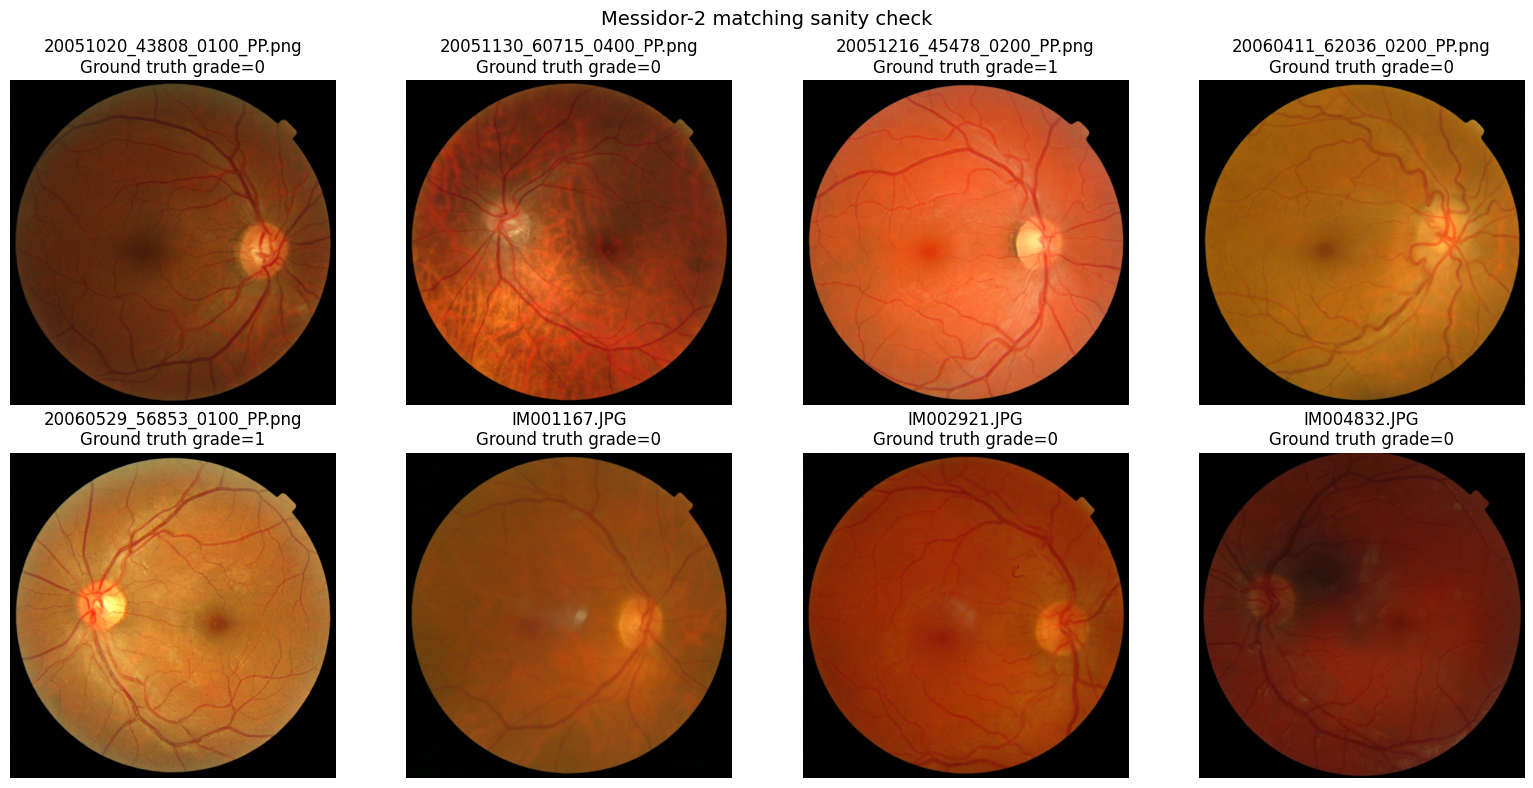

Inspect these examples before continuing. The displayed filename should correspond to the CSV row and its ground-truth grade.


In [12]:

# Cell 11 — Visual sanity check of filename/label matching
n_show = min(8, len(ext))
sample = ext.iloc[np.linspace(0, len(ext) - 1, n_show, dtype=int)]

plt.figure(figsize=(16, 8))
for i, (_, row) in enumerate(sample.iterrows()):
    img = cv2.imread(str(row["filepath"]))
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax = plt.subplot(2, 4, i + 1)
    ax.imshow(img)
    ax.set_title(f"{Path(row['filepath']).name}\nGround truth grade={row['label']}")
    ax.axis("off")

plt.suptitle("Messidor-2 matching sanity check", fontsize=14)
plt.tight_layout()
plt.show()

print(
    "Inspect these examples before continuing. "
    "The displayed filename should correspond to the CSV row and its ground-truth grade."
)


In [13]:

# Cell 12 — Exact classifier preprocessing used by the final model
def tf_crop_black_border(img, threshold=10.0):
    gray = tf.reduce_mean(img, axis=-1)
    coords = tf.where(gray > threshold)

    def do_crop():
        y0 = tf.reduce_min(coords[:, 0])
        y1 = tf.reduce_max(coords[:, 0]) + 1
        x0 = tf.reduce_min(coords[:, 1])
        x1 = tf.reduce_max(coords[:, 1]) + 1
        return img[y0:y1, x0:x1, :]

    return tf.cond(
        tf.shape(coords)[0] > 0,
        do_crop,
        lambda: img,
    )

def decode_classifier_image(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(
        img,
        channels=3,
        expand_animations=False,
    )
    img.set_shape([None, None, 3])
    img = tf.cast(img, tf.float32)

    # Safe even though this Kaggle Messidor version is already cropped.
    img = tf_crop_black_border(img)

    img = tf.image.resize(
        img,
        CLS_SIZE,
        antialias=True,
    )

    # IMPORTANT: final Keras EfficientNet expects 0–255 float pixels.
    # Do NOT divide by 255 here.
    return tf.clip_by_value(img, 0.0, 255.0)

def temperature_scale(probs, temperature=TEMPERATURE):
    probs = np.clip(
        np.asarray(probs, dtype=np.float64),
        1e-12,
        1.0,
    )
    logits = np.log(probs) / float(temperature)
    logits -= logits.max(axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / exp_logits.sum(axis=1, keepdims=True)

# Sanity-check one input.
example = decode_classifier_image(tf.constant(str(ext.iloc[0]["filepath"])))
print("Classifier input shape:", example.shape)
print("Pixel min/max:", float(tf.reduce_min(example)), float(tf.reduce_max(example)))

if float(tf.reduce_max(example)) <= 1.5:
    raise RuntimeError(
        "Classifier pixels unexpectedly look normalized to 0–1. "
        "The final model expects 0–255 float input."
    )


Classifier input shape: (300, 300, 3)
Pixel min/max: 0.0 253.61663818359375


In [14]:

# Cell 13 — Run external inference on all matched Messidor images
def make_external_ds(df, batch_size=24):
    paths = df["filepath"].astype(str).to_numpy()

    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(
        decode_classifier_image,
        num_parallel_calls=tf.data.AUTOTUNE,
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

ext_ds = make_external_ds(ext, batch_size=24)

print("Running final classifier on", len(ext), "external Messidor images...")
raw_probs = model.predict(ext_ds, verbose=1)

if raw_probs.shape != (len(ext), 5):
    raise RuntimeError(
        f"Unexpected prediction shape: {raw_probs.shape}; "
        f"expected ({len(ext)}, 5)."
    )

if not np.isfinite(raw_probs).all():
    raise RuntimeError("Non-finite classifier probabilities detected.")

cal_probs = temperature_scale(raw_probs)

print("Prediction matrix:", cal_probs.shape)
print(
    "Calibrated probability row sums:",
    float(cal_probs.sum(axis=1).min()),
    "to",
    float(cal_probs.sum(axis=1).max()),
)


Running final classifier on 1744 external Messidor images...
73/73 ━━━━━━━━━━━━━━━━━━━━ 55s 479ms/step
Prediction matrix: (1744, 5)
Calibrated probability row sums: 0.9999999999999996 to 1.0000000000000004


In [15]:

# Cell 14 — Quantitative external validation
y_true = ext["label"].to_numpy(dtype=int)

pred_grade = np.argmax(cal_probs, axis=1).astype(int)

# Referable DR definition: grade >= 2.
y_ref = (y_true >= 2).astype(int)

# Same screening score used in the final system.
p_ref = cal_probs[:, 2:5].sum(axis=1)

# IMPORTANT: fixed APTOS-validation threshold; NEVER tuned on Messidor.
pred_ref = (p_ref >= REF_THRESHOLD).astype(int)

if len(np.unique(y_ref)) < 2:
    raise RuntimeError(
        "Messidor labels contain only one referable class; AUC cannot be computed."
    )

ext_auc = roc_auc_score(y_ref, p_ref)

tn, fp, fn, tp = confusion_matrix(
    y_ref,
    pred_ref,
    labels=[0, 1],
).ravel()

sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
specificity = tn / (tn + fp) if (tn + fp) else np.nan

observed_grades = sorted(np.unique(y_true).tolist())
scale_max = int(np.max(y_true))

results = {
    "dataset": "Messidor-2 preprocessed external test",
    "n": int(len(ext)),
    "observed_ground_truth_grades": observed_grades,
    "temperature_frozen_from_aptos_validation": float(TEMPERATURE),
    "referral_threshold_frozen_from_aptos_validation": float(REF_THRESHOLD),
    "referable_auc": float(ext_auc),
    "sensitivity": float(sensitivity),
    "specificity": float(specificity),
    "screening_confusion_counts": {
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    },
}

# Only claim direct five-class comparability when the external labels visibly use 0–4.
if scale_max == 4:
    results["five_class_accuracy"] = float(
        accuracy_score(y_true, pred_grade)
    )
    results["quadratic_weighted_kappa"] = float(
        cohen_kappa_score(
            y_true,
            pred_grade,
            weights="quadratic",
        )
    )
    exact_grade_comparable = True
else:
    exact_grade_comparable = False
    print(
        "WARNING: maximum external DR grade is not 4. "
        "Binary referable-DR metrics remain valid, but direct APTOS 0–4 "
        "five-class comparison will not be claimed."
    )

print("=" * 72)
print("MESSIDOR-2 EXTERNAL VALIDATION RESULTS")
print("=" * 72)
print(json.dumps(results, indent=2))


MESSIDOR-2 EXTERNAL VALIDATION RESULTS
{
  "dataset": "Messidor-2 preprocessed external test",
  "n": 1744,
  "observed_ground_truth_grades": [
    0,
    1,
    2,
    3,
    4
  ],
  "temperature_frozen_from_aptos_validation": 0.8320230381499122,
  "referral_threshold_frozen_from_aptos_validation": 0.3188608191210113,
  "referable_auc": 0.7549149124641465,
  "sensitivity": 0.2013129102844639,
  "specificity": 0.9821289821289821,
  "screening_confusion_counts": {
    "tn": 1264,
    "fp": 23,
    "fn": 365,
    "tp": 92
  },
  "five_class_accuracy": 0.5928899082568807,
  "quadratic_weighted_kappa": 0.20507716247850583
}


In [16]:

# Cell 15 — Detailed classification report
if exact_grade_comparable:
    report_dict = classification_report(
        y_true,
        pred_grade,
        labels=[0, 1, 2, 3, 4],
        target_names=[
            "Grade 0",
            "Grade 1",
            "Grade 2",
            "Grade 3",
            "Grade 4",
        ],
        output_dict=True,
        zero_division=0,
    )
    report_df = pd.DataFrame(report_dict).T
    display(report_df)

    report_path = EXTERNAL_OUTPUT_ROOT / "messidor2_classification_report.csv"
    report_df.to_csv(report_path)
    print("Saved:", report_path)
else:
    print("Exact five-class report skipped because the detected external scale was not 0–4.")


,precision,recall,f1-score,support
Grade 0,0.599408,0.996067,0.748430,1017.00000
Grade 1,0.000000,0.000000,0.000000,270.00000
Grade 2,0.206897,0.017291,0.031915,347.00000
Grade 3,0.857143,0.080000,0.146341,75.00000
Grade 4,0.500000,0.257143,0.339623,35.00000
accuracy,0.592890,0.592890,0.592890,0.59289
macro avg,0.432690,0.270100,0.253262,1744.00000
weighted avg,0.437602,0.592890,0.455900,1744.00000


Saved: /content/drive/MyDrive/sih/outputs_v3_fixed/messidor_external_validation/messidor2_classification_report.csv


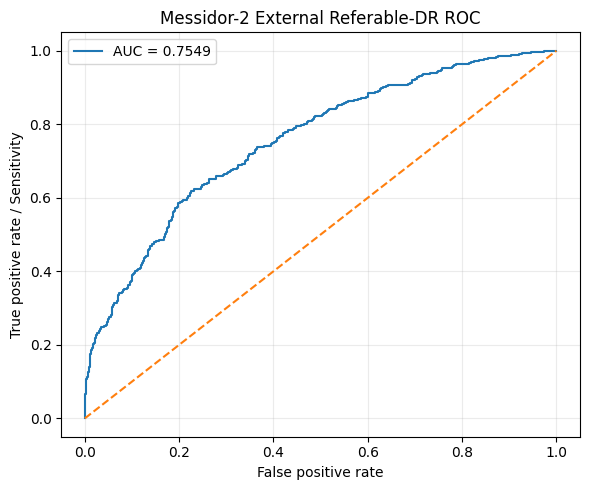

Saved: /content/drive/MyDrive/sih/outputs_v3_fixed/messidor_external_validation/messidor2_referable_roc.png


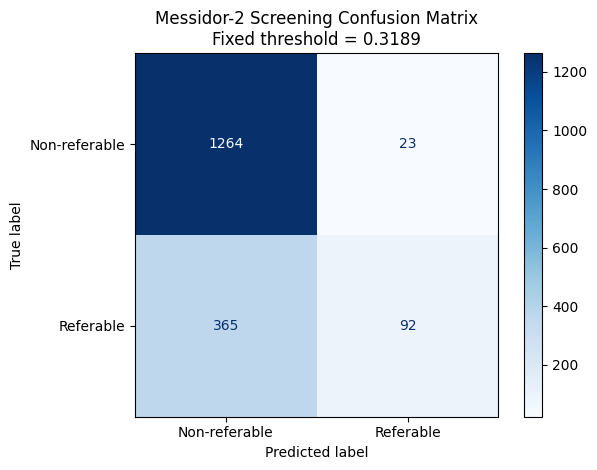

Saved: /content/drive/MyDrive/sih/outputs_v3_fixed/messidor_external_validation/messidor2_screening_confusion_matrix.png


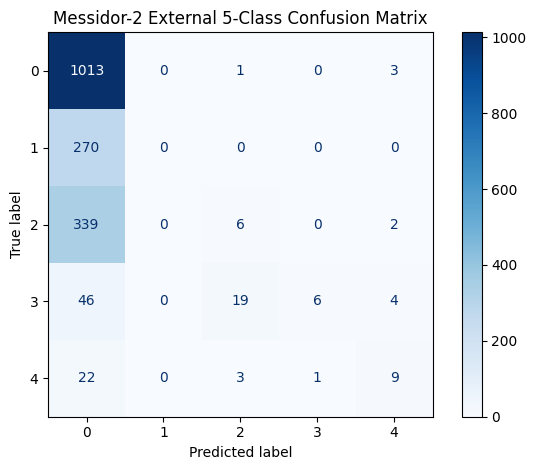

Saved: /content/drive/MyDrive/sih/outputs_v3_fixed/messidor_external_validation/messidor2_5class_confusion_matrix.png


In [17]:

# Cell 16 — External ROC curve and confusion matrices
# ROC
fpr, tpr, _ = roc_curve(y_ref, p_ref)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {ext_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate / Sensitivity")
plt.title("Messidor-2 External Referable-DR ROC")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

roc_path = EXTERNAL_OUTPUT_ROOT / "messidor2_referable_roc.png"
plt.savefig(roc_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", roc_path)

# Binary screening confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_ref,
    pred_ref,
    labels=[0, 1],
    display_labels=["Non-referable", "Referable"],
    cmap="Blues",
)
plt.title(
    f"Messidor-2 Screening Confusion Matrix\n"
    f"Fixed threshold = {REF_THRESHOLD:.4f}"
)
plt.tight_layout()

binary_cm_path = EXTERNAL_OUTPUT_ROOT / "messidor2_screening_confusion_matrix.png"
plt.savefig(binary_cm_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", binary_cm_path)

# Five-class confusion matrix when scale is 0–4.
if exact_grade_comparable:
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        pred_grade,
        labels=[0, 1, 2, 3, 4],
        cmap="Blues",
    )
    plt.title("Messidor-2 External 5-Class Confusion Matrix")
    plt.tight_layout()

    grade_cm_path = EXTERNAL_OUTPUT_ROOT / "messidor2_5class_confusion_matrix.png"
    plt.savefig(grade_cm_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved:", grade_cm_path)


In [18]:

# Cell 17 — Save every external prediction
predictions = ext[
    [IMAGE_COL, GRADE_COL, "filepath", "label"]
].copy()

predictions = predictions.rename(
    columns={
        IMAGE_COL: "csv_image_reference",
        GRADE_COL: "ground_truth_grade_raw",
        "label": "ground_truth_grade",
    }
)

predictions["predicted_grade"] = pred_grade
predictions["referable_true"] = y_ref
predictions["referable_probability"] = p_ref
predictions["referable_prediction"] = pred_ref

for grade in range(5):
    predictions[f"p_grade_{grade}"] = cal_probs[:, grade]

predictions_path = EXTERNAL_OUTPUT_ROOT / "messidor2_external_predictions.csv"
predictions.to_csv(predictions_path, index=False)

metrics_path = EXTERNAL_OUTPUT_ROOT / "messidor2_external_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

print("Saved:", predictions_path)
print("Saved:", metrics_path)


Saved: /content/drive/MyDrive/sih/outputs_v3_fixed/messidor_external_validation/messidor2_external_predictions.csv
Saved: /content/drive/MyDrive/sih/outputs_v3_fixed/messidor_external_validation/messidor2_external_metrics.json


In [19]:

# Cell 18 — APTOS internal vs Messidor external comparison table
internal = previous_summary.get("classifier", {})

def first_present(mapping, keys, default=np.nan):
    for key in keys:
        if key in mapping and mapping[key] is not None:
            return mapping[key]
    return default

comparison_rows = [
    {
        "dataset": "APTOS held-out test",
        "evaluation_role": "internal held-out test",
        "n": int(previous_summary.get("aptos_test_rows", 550)),
        "five_class_accuracy": first_present(
            internal,
            ["aptos_test_accuracy", "test_accuracy", "accuracy"],
            0.7727272727,
        ),
        "qwk": first_present(
            internal,
            ["aptos_test_qwk", "test_qwk", "qwk"],
            0.8201732876,
        ),
        "referable_auc": first_present(
            internal,
            ["aptos_test_referable_auc", "referable_auc", "test_referable_auc"],
            0.9698852182,
        ),
        "sensitivity": first_present(
            internal,
            ["aptos_test_sensitivity", "sensitivity", "test_sensitivity"],
            0.9058295964,
        ),
        "specificity": first_present(
            internal,
            ["aptos_test_specificity", "specificity", "test_specificity"],
            0.8899082569,
        ),
    },
    {
        "dataset": "Messidor-2 preprocessed",
        "evaluation_role": "external test",
        "n": int(len(ext)),
        "five_class_accuracy": results.get("five_class_accuracy"),
        "qwk": results.get("quadratic_weighted_kappa"),
        "referable_auc": results.get("referable_auc"),
        "sensitivity": results.get("sensitivity"),
        "specificity": results.get("specificity"),
    },
]

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

comparison_path = EXTERNAL_OUTPUT_ROOT / "aptos_vs_messidor_external_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)


,dataset,evaluation_role,n,five_class_accuracy,qwk,referable_auc,sensitivity,specificity
0,APTOS held-out test,internal held-out test,550,0.772727,0.820173,0.969885,0.905830,0.889908
1,Messidor-2 preprocessed,external test,1744,0.592890,0.205077,0.754915,0.201313,0.982129


Saved: /content/drive/MyDrive/sih/outputs_v3_fixed/messidor_external_validation/aptos_vs_messidor_external_comparison.csv


In [20]:

# Cell 19 — Final validation summary and scientifically safe wording
final_external_summary = {
    "external_dataset": "Messidor-2 preprocessed",
    "source_zip": str(MESSIDOR_ZIP),
    "csv": str(MESSIDOR_CSV),
    "image_root": str(MESSIDOR_IMAGE_ROOT),
    "csv_rows": int(rows_total),
    "images_found": int(len(image_index)),
    "matched_labeled_images_evaluated": int(len(ext)),
    "image_column": str(IMAGE_COL),
    "dr_grade_column": str(GRADE_COL),
    "gradability_column": (
        str(GRADABLE_COL) if GRADABLE_COL is not None else None
    ),
    "results": results,
    "methodology_note": (
        "No Messidor retraining or threshold tuning was performed. "
        "The final APTOS-trained EfficientNetB0 classifier was used unchanged. "
        "Temperature and referral threshold were frozen from APTOS validation. "
        "Referable DR was defined as grade >= 2."
    ),
    "reporting_note": (
        "These results are external-dataset evaluation of a research/college "
        "screening prototype and are not clinical validation."
    ),
}

summary_path = EXTERNAL_OUTPUT_ROOT / "messidor2_external_validation_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(final_external_summary, f, indent=2)

print("=" * 80)
print("FINAL EXTERNAL VALIDATION COMPLETE")
print("=" * 80)
print("Images evaluated:", len(ext))
print(f"Referable AUC: {results['referable_auc']:.4f}")
print(f"Sensitivity:   {results['sensitivity']:.4f}")
print(f"Specificity:   {results['specificity']:.4f}")

if exact_grade_comparable:
    print(f"5-class accuracy: {results['five_class_accuracy']:.4f}")
    print(f"QWK:              {results['quadratic_weighted_kappa']:.4f}")

print("\nSafe report wording:")
print(
    f"The frozen APTOS-trained classifier was externally evaluated on "
    f"{len(ext)} matched, labeled images from the preprocessed Messidor-2 "
    f"dataset. No Messidor retraining or threshold tuning was performed."
)

print("\nOutputs saved to:")
print(EXTERNAL_OUTPUT_ROOT)

print("\nSaved files:")
for p in sorted(EXTERNAL_OUTPUT_ROOT.iterdir()):
    if p.is_file():
        print(" -", p.name)


FINAL EXTERNAL VALIDATION COMPLETE
Images evaluated: 1744
Referable AUC: 0.7549
Sensitivity:   0.2013
Specificity:   0.9821
5-class accuracy: 0.5929
QWK:              0.2051

Safe report wording:
The frozen APTOS-trained classifier was externally evaluated on 1744 matched, labeled images from the preprocessed Messidor-2 dataset. No Messidor retraining or threshold tuning was performed.

Outputs saved to:
/content/drive/MyDrive/sih/outputs_v3_fixed/messidor_external_validation

Saved files:
 - aptos_vs_messidor_external_comparison.csv
 - messidor2_5class_confusion_matrix.png
 - messidor2_classification_report.csv
 - messidor2_external_metrics.json
 - messidor2_external_predictions.csv
 - messidor2_external_validation_summary.json
 - messidor2_matched_manifest.csv
 - messidor2_referable_roc.png
 - messidor2_screening_confusion_matrix.png



## How to interpret the final run

After running every cell, use the values printed in **Cell 19** as the final external-validation results.

### Important reporting rules

You may now say that the classifier was **quantitatively externally evaluated on the labeled preprocessed Messidor-2 dataset**, provided the notebook successfully matches the CSV and images and produces the metrics.

Do **not** say:

- that the model was trained on Messidor-2;
- that the referral threshold was optimized on Messidor-2;
- that this is clinical validation;
- that U-Net segmentation was quantitatively externally validated by this notebook.

This notebook validates the **DR classifier / referable-screening task** using external Messidor labels.
